# Right-Censored Warm-Start and CV-EM Demo

This notebook compares five right-censored fits on the same dataset:

1. `cv-IPCW` Stage 1 initializer,
2. `EM` without oversmooth,
3. `CV-EM` with CV over `oversmooth_factor` and `em_norm_factor`,
4. fixed-support observed `L1` refit with a cold start,
5. fixed-support observed `L1` refit with the natural Stage 1 warm start.

The main practical questions are:

- does the Stage 1 warm start help the fixed-support observed `L1` refit?
- how does `CV-EM` compare with `EM` and warm-started observed `L1`?
- how do the methods compare on exact score diagnostics and pointwise density/survival MSE?

For observed `L1`, the warm start is the Stage 1 coefficient vector compressed onto the fixed selected support.

## Run Configuration

The key settings for this notebook are collected in the next code cell so they are easy to find and edit.

In particular:

- the representative run uses `REPRESENTATIVE_SEED`,
- the small Monte Carlo sweep uses `SMALL_MC_N_SEEDS` seeds,
- the small Monte Carlo sweep runs in parallel with `SMALL_MC_N_WORKERS` workers,
- the `CV-EM` refit cross-validates `oversmooth_factor` and `em_norm_factor`,
- the pointwise MSE grid is `0.05, 0.10, ..., 0.95`,
- the exact score diagnostics use fixed sampling and quadrature settings.

In [1]:
from __future__ import annotations

from contextlib import contextmanager
from pathlib import Path
import sys
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from joblib import Parallel, delayed
from tqdm import tqdm

ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "pyproject.toml").exists() and (p / "src").exists()
)
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from haldensity.censoring.right import (
    KaplanMeier,
    RightCensoredEMStage,
    RightCensoredObservedL1MLE,
    right_censored_observed_loglik_and_gradient,
)
from haldensity.censoring.right.comparison import (
    evaluate_density_on_grid,
    evaluate_survival_on_grid,
)
from haldensity.censoring.right.metrics import incomplete_loglik
from haldensity.censoring.tuners.right_tuners import (
    RightCensoredCVOversmoothEMTuner,
    RightCensoredInitTuner,
)
from haldensity.utils import TruncatedGMM

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=4, suppress=True)

# Representative single-seed run.
REPRESENTATIVE_SEED = 3

# Shared estimation settings.
N = 200
CV_FOLDS = 5
N_TRIALS = 25
CV_OVERSMOOTH_EM_N_TRIALS = 20
N_GRID_POINTS = 200

# Reference DGP from examples/example_right_censored_density_estimator.ipynb.
REFERENCE_GMM_COMPONENTS = [
    {"mean": 0.2, "std": 0.05, "lower": 0.0, "upper": 1.0},
    {"mean": 0.5, "std": 0.05, "lower": 0.0, "upper": 1.0},
    {"mean": 0.8, "std": 0.05, "lower": 0.0, "upper": 1.0},
]
REFERENCE_GMM_WEIGHTS = [0.33, 0.34, 0.33]

# CV-oversmooth EM settings.
CV_OVERSMOOTH_FACTORS = [0.1, 1.0]
CV_OVERSMOOTH_EM_NORM_FACTORS = [1.0, 2.0]

# Small Monte Carlo sweep settings.
SMALL_MC_N_SEEDS = 50
SMALL_MC_SEEDS = list(range(1, SMALL_MC_N_SEEDS + 1))
SMALL_MC_N_WORKERS = 5

# Pointwise MSE grid for small-MC summaries.
POINTWISE_MSE_GRID = np.arange(0.05, 1.00, 0.05)

# Exact score diagnostic settings.
SCORE_N_DIRECTIONS = 40
SCORE_QUADRATURE_N = 2001
SCORE_SEED_MULTIPLIER = 100

# Backward-compatible aliases used below.
SEED_SWEEP = SMALL_MC_SEEDS
N_WORKERS = SMALL_MC_N_WORKERS

STAGE1_OVERRIDES = {
    "basis_order": [0, 1, 2],
    "norm_constraint": {"low": 1.0, "high": 500.0, "log": False},
}
EM_STAGE_KWARGS = {
    "m_imputations": 40,
    "max_em_iter": 10,
    "em_tol": 1e-3,
    "n_grid_points": N_GRID_POINTS,
    "use_sc_adjustment": False,
    "e_step_n_grid": 200,
    "tol": 1e-6,
    "m_step_solver": "CLARABEL",
    "include_intercept_in_constraint": False,
    "verbose": False,
}
OBSERVED_L1_KWARGS = {
    "n_grid_points": N_GRID_POINTS,
    "learning_rate": 0.1,
    "n_iterations": 30000,
    "ll_change_tol": 1e-4,
    "include_intercept_in_constraint": False,
    "history_every": 100,
}

run_config = pd.DataFrame(
    [
        {
            "representative_seed": REPRESENTATIVE_SEED,
            "dgp": "TruncatedGMM + Uniform censoring",
            "stage1_n_trials": N_TRIALS,
            "cvem_n_trials": CV_OVERSMOOTH_EM_N_TRIALS,
            "cvem_oversmooth_range": f"{CV_OVERSMOOTH_FACTORS[0]}-{CV_OVERSMOOTH_FACTORS[-1]}",
            "cvem_em_norm_range": f"{CV_OVERSMOOTH_EM_NORM_FACTORS[0]}-{CV_OVERSMOOTH_EM_NORM_FACTORS[-1]}",
            "small_mc_n_seeds": SMALL_MC_N_SEEDS,
            "small_mc_seed_range": f"{SMALL_MC_SEEDS[0]}-{SMALL_MC_SEEDS[-1]}",
            "small_mc_n_workers": SMALL_MC_N_WORKERS,
            "pointwise_mse_grid": "0.05:0.95:0.05",
            "score_n_directions": SCORE_N_DIRECTIONS,
            "score_quadrature_n": SCORE_QUADRATURE_N,
        }
    ]
)
display(run_config)

/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,representative_seed,dgp,stage1_n_trials,cvem_n_trials,cvem_oversmooth_range,cvem_em_norm_range,small_mc_n_seeds,small_mc_seed_range,small_mc_n_workers,pointwise_mse_grid,score_n_directions,score_quadrature_n
0,3,TruncatedGMM + Uniform censoring,25,20,0.1-1.0,1.0-2.0,50,1-50,5,0.05:0.95:0.05,40,2001


In [2]:
# Stage-1 / EM / observed-L1 fitting helpers.

def simulate_reference_right_censored_dgp(n: int, *, seed: int) -> dict:
    np.random.seed(seed)
    sampler = TruncatedGMM(components=REFERENCE_GMM_COMPONENTS, weights=REFERENCE_GMM_WEIGHTS)
    t_event = sampler.generate_samples(n)
    t_cens = np.random.uniform(0.0, 1.0, size=n)
    observed_time = np.minimum(t_event, t_cens)
    delta = (t_event <= t_cens).astype(int)

    return {
        "observed_data": pd.DataFrame({"T": observed_time, "Delta": delta}),
        "truth": {
            "density_fn": lambda t, _sampler=sampler: _sampler.compute_density(np.asarray(t, dtype=float)),
            "survival_fn": lambda t, _sampler=sampler: 1.0 - _sampler.compute_cdf(np.asarray(t, dtype=float)),
        },
        "event_time": t_event,
        "censor_time": t_cens,
    }


def fit_stage1_cv_ipcw(data: pd.DataFrame, *, seed: int) -> dict:
    tic = time.perf_counter()
    tuner = RightCensoredInitTuner(
        data=data,
        cv_folds=CV_FOLDS,
        random_state=seed,
        n_grid_points=N_GRID_POINTS,
        param_overrides=STAGE1_OVERRIDES,
        use_conservative_adjustment=False,
        silent=True,
        validation_metric="ipcw_loglik",
    )
    result = tuner.optimize(n_trials=N_TRIALS)
    runtime_seconds = time.perf_counter() - tic
    return {
        "tuning_result": result,
        "estimator": result.estimator,
        "runtime_seconds": float(runtime_seconds),
    }


def compress_theta_to_selected_support(estimator) -> np.ndarray:
    support = np.asarray(estimator.grid_points_hal_selected, dtype=float)
    all_knots = np.asarray(estimator._grid_points_hal, dtype=float)
    theta_full = np.asarray(estimator.theta_hat, dtype=float)
    basis_order = int(estimator.basis_order)
    poly_cols = basis_order if basis_order > 0 else 0
    knot_start = 1 + poly_cols

    theta_selected = np.zeros(knot_start + support.size, dtype=float)
    theta_selected[:knot_start] = theta_full[:knot_start]
    for i, knot in enumerate(support):
        idx = np.where(np.isclose(all_knots, knot, atol=1e-10, rtol=0.0))[0]
        if idx.size == 0:
            raise RuntimeError("selected support knot was not found in the full Stage 1 grid")
        theta_selected[knot_start + i] = theta_full[knot_start + int(idx[0])]
    return theta_selected


def run_em_no_oversmooth(data: pd.DataFrame, stage1_estimator, *, seed: int) -> dict:
    km = KaplanMeier().fit(data, time_col="T", delta_col="Delta")
    stage = RightCensoredEMStage(
        norm_constraint=float(stage1_estimator.norm_constraint),
        rng_seed=seed,
        **EM_STAGE_KWARGS,
    )

    tic = time.perf_counter()
    result = stage.run(
        initial_estimator=stage1_estimator,
        data=data,
        S_c_predict=lambda t: np.atleast_1d(km.predict(t)),
    )
    runtime_seconds = time.perf_counter() - tic

    estimator = result.final_estimator
    return {
        "estimator": estimator,
        "results": estimator.get_results(),
        "runtime_seconds": float(runtime_seconds),
        "em_iterations": int(result.em_iterations),
        "em_converged": bool(result.em_converged),
        "observed_loglik": float(incomplete_loglik(estimator, data)),
    }


def fit_cv_oversmooth_em(data: pd.DataFrame, stage1_estimator, *, seed: int) -> dict:
    tic = time.perf_counter()
    tuning_result = RightCensoredCVOversmoothEMTuner(
        data=data,
        stage1_estimator=stage1_estimator,
        cv_folds=CV_FOLDS,
        oversmooth_factors=CV_OVERSMOOTH_FACTORS,
        em_norm_factors=CV_OVERSMOOTH_EM_NORM_FACTORS,
        em_m_imputations=EM_STAGE_KWARGS["m_imputations"],
        em_max_em_iter=EM_STAGE_KWARGS["max_em_iter"],
        em_tol=EM_STAGE_KWARGS["em_tol"],
        em_e_step_n_grid=EM_STAGE_KWARGS["e_step_n_grid"],
        em_use_sc_adjustment=EM_STAGE_KWARGS["use_sc_adjustment"],
        n_grid_points=N_GRID_POINTS,
        random_state=seed,
        solver=EM_STAGE_KWARGS["m_step_solver"],
        silent=True,
    ).optimize(n_trials=CV_OVERSMOOTH_EM_N_TRIALS)
    runtime_seconds = time.perf_counter() - tic

    estimator = tuning_result.estimator
    best_record = tuning_result.metadata["best_record"]
    return {
        "estimator": estimator,
        "tuning_result": tuning_result,
        "runtime_seconds": float(runtime_seconds),
        "observed_loglik": float(incomplete_loglik(estimator, data)),
        "best_oversmooth_factor": float(tuning_result.best_params["oversmooth_factor"]),
        "best_em_norm_factor": float(tuning_result.best_params["em_norm_factor"]),
        "best_cv_loglik": float(best_record.mean_cv_ll),
        "best_cv_sd": float(best_record.sd_cv_ll),
    }


def fit_observed_l1(data: pd.DataFrame, stage1_estimator, *, use_warm_start: bool) -> dict:
    warm_start = compress_theta_to_selected_support(stage1_estimator) if use_warm_start else None
    tic = time.perf_counter()
    estimator = RightCensoredObservedL1MLE(
        working_grid_points=np.asarray(stage1_estimator.grid_points_hal_selected, dtype=float),
        norm_constraint=float(stage1_estimator.norm_constraint),
        basis_order=int(stage1_estimator.basis_order),
        warm_start_theta=warm_start,
        **OBSERVED_L1_KWARGS,
    ).fit(data)
    runtime_seconds = time.perf_counter() - tic

    results = estimator.get_results()
    return {
        "estimator": estimator,
        "results": results,
        "runtime_seconds": float(runtime_seconds),
        "n_iterations_run": int(results["n_iterations_run"]),
        "converged": bool(results["converged"]),
        "observed_loglik": float(incomplete_loglik(estimator, data)),
        "warm_start": bool(use_warm_start),
    }


def l1_history_frame(run: dict, label: str) -> pd.DataFrame:
    hist = pd.DataFrame(run["results"]["optimization_history"])
    if hist.empty:
        return hist
    hist = hist.copy()
    hist["run"] = label
    return hist


def summarize_warm_delta(cold_run: dict, warm_run: dict, *, family: str) -> dict:
    return {
        "family": family,
        "runtime_gain_ms": 1000.0 * (cold_run["runtime_seconds"] - warm_run["runtime_seconds"]),
        "observed_loglik_gain": warm_run["observed_loglik"] - cold_run["observed_loglik"],
        "iteration_gain": cold_run["n_iterations_run"] - warm_run["n_iterations_run"],
    }


# Shared-support score helpers.

def compress_to_selected_support(estimator, *, coef_tol: float = 1e-8) -> dict:
    basis_order = int(estimator.basis_order)
    theta_full = np.asarray(estimator.theta_hat, dtype=float).copy()
    selected_knots = np.asarray(estimator.grid_points_hal_selected, dtype=float).copy()
    all_knots = np.asarray(estimator._grid_points_hal, dtype=float).copy()
    poly_cols = basis_order if basis_order > 0 else 0
    knot_start = 1 + poly_cols

    theta_selected = np.zeros(knot_start + len(selected_knots), dtype=float)
    theta_selected[:knot_start] = theta_full[:knot_start]
    for i, knot in enumerate(selected_knots):
        idx = np.where(np.isclose(all_knots, knot, atol=1e-10, rtol=0.0))[0]
        if idx.size == 0:
            raise ValueError(f"Unable to match selected knot {knot} in full working grid")
        theta_selected[knot_start + i] = theta_full[knot_start + int(idx[0])]

    return {
        "theta_hat": theta_selected,
        "working_grid_points": selected_knots,
        "basis_order": basis_order,
        "include_intercept_in_constraint": bool(getattr(estimator, "include_intercept_in_constraint", False)),
        "norm_constraint": float(getattr(estimator, "norm_constraint", np.nan)),
        "coef_tol": float(getattr(estimator, "tol", coef_tol)),
    }


def sample_l1_constant_direction(theta, *, include_intercept_in_constraint=False, coef_tol=1e-8, rng, max_tries=64):
    start_idx = 0 if include_intercept_in_constraint else 1
    active = np.where(np.abs(theta[start_idx:]) > float(coef_tol))[0] + start_idx
    if active.size < 2:
        return None, active

    weights = np.abs(theta[active])
    denom = float(np.dot(weights, weights))
    if not np.isfinite(denom) or denom <= 0.0:
        return None, active

    for _ in range(int(max_tries)):
        h = rng.normal(size=active.size)
        h -= float(np.dot(h, weights)) / denom * weights
        max_abs = float(np.max(np.abs(h)))
        if np.isfinite(max_abs) and max_abs > 1e-10:
            return h / max_abs, active
    return None, active


def exact_constraint_score(theta, grad, h, active_idx):
    velocity = theta[active_idx] * h
    return float(np.dot(grad[active_idx], velocity))


def score_rng_seed(seed: int, offset: int) -> int:
    return int(seed * SCORE_SEED_MULTIPLIER + offset)


def score_diagnostics(
    estimator,
    observed_df: pd.DataFrame,
    *,
    rng_seed: int,
    n_directions: int = SCORE_N_DIRECTIONS,
    quadrature_n: int = SCORE_QUADRATURE_N,
) -> dict:
    state = compress_to_selected_support(estimator)
    theta = np.asarray(state["theta_hat"], dtype=float)
    ll, grad = right_censored_observed_loglik_and_gradient(
        theta,
        observed_df,
        working_grid_points=state["working_grid_points"],
        basis_order=state["basis_order"],
        n_grid_points=quadrature_n,
        min_tail_mass=1e-12,
    )

    n_obs = float(observed_df.shape[0])
    ll = float(ll) / n_obs
    grad = np.asarray(grad, dtype=float) / n_obs

    start_idx = 0 if state["include_intercept_in_constraint"] else 1
    penalized_grad = grad[start_idx:]

    rng = np.random.default_rng(int(rng_seed))
    abs_constraint_scores = []
    for _ in range(int(n_directions)):
        h, active_idx = sample_l1_constant_direction(
            theta,
            include_intercept_in_constraint=state["include_intercept_in_constraint"],
            coef_tol=state["coef_tol"],
            rng=rng,
        )
        if h is None:
            break
        abs_constraint_scores.append(abs(exact_constraint_score(theta, grad, h, active_idx)))

    return {
        "observed_loglik": ll,
        "max_abs_observed_score": float(np.max(np.abs(penalized_grad))) if penalized_grad.size else 0.0,
        "l2_observed_score": float(np.linalg.norm(penalized_grad)),
        "n_constraint_directions": int(len(abs_constraint_scores)),
        "median_abs_constraint_score": float(np.median(abs_constraint_scores)) if abs_constraint_scores else float("nan"),
        "max_abs_constraint_score": float(np.max(abs_constraint_scores)) if abs_constraint_scores else float("nan"),
    }


# Truth-on-grid error helpers.

def pointwise_mse_on_grid(estimator, truth: dict, *, grid: np.ndarray = POINTWISE_MSE_GRID) -> dict:
    eval_grid = np.asarray(grid, dtype=float)
    est_density = evaluate_density_on_grid(estimator, eval_grid)
    est_survival = evaluate_survival_on_grid(estimator, eval_grid)
    truth_density = np.asarray(truth["density_fn"](eval_grid), dtype=float)
    truth_survival = np.asarray(truth["survival_fn"](eval_grid), dtype=float)

    return {
        "density_pointwise_mse": float(np.mean(np.square(est_density - truth_density))),
        "survival_pointwise_mse": float(np.mean(np.square(est_survival - truth_survival))),
    }


def build_method_summary_row(
    *,
    seed: int,
    method: str,
    family: str,
    estimator,
    score: dict,
    mse: dict,
    runtime_seconds: float = np.nan,
    em_iterations: float = np.nan,
    optimizer_iterations: float = np.nan,
    cv_oversmooth_factor: float = np.nan,
    cv_em_norm_factor: float = np.nan,
) -> dict:
    return {
        "seed": int(seed),
        "method": method,
        "family": family,
        "runtime_seconds": float(runtime_seconds),
        "observed_loglik": float(score["observed_loglik"]),
        "max_abs_observed_score": float(score["max_abs_observed_score"]),
        "median_abs_constraint_score": float(score["median_abs_constraint_score"]),
        "density_pointwise_mse": float(mse["density_pointwise_mse"]),
        "survival_pointwise_mse": float(mse["survival_pointwise_mse"]),
        "support_size": int(len(estimator.grid_points_hal_selected)),
        "em_iterations": float(em_iterations),
        "optimizer_iterations": float(optimizer_iterations),
        "cv_oversmooth_factor": float(cv_oversmooth_factor),
        "cv_em_norm_factor": float(cv_em_norm_factor),
    }


def build_pointwise_rows(
    *,
    seed: int,
    method: str,
    estimator,
    truth: dict,
    grid: np.ndarray = POINTWISE_MSE_GRID,
) -> list[dict]:
    eval_grid = np.asarray(grid, dtype=float)
    density_est = np.asarray(evaluate_density_on_grid(estimator, eval_grid), dtype=float)
    survival_est = np.asarray(evaluate_survival_on_grid(estimator, eval_grid), dtype=float)
    truth_density = np.asarray(truth["density_fn"](eval_grid), dtype=float)
    truth_survival = np.asarray(truth["survival_fn"](eval_grid), dtype=float)

    rows = []
    for estimand, estimates, truths in [
        ("density", density_est, truth_density),
        ("survival", survival_est, truth_survival),
    ]:
        for eval_point, estimate, truth_value in zip(eval_grid, estimates, truths):
            error = float(estimate - truth_value)
            rows.append(
                {
                    "seed": int(seed),
                    "method": method,
                    "estimand": estimand,
                    "eval_point": float(eval_point),
                    "estimate": float(estimate),
                    "truth": float(truth_value),
                    "error": error,
                    "squared_error": float(error ** 2),
                }
            )
    return rows


# Parallel small-MC helpers.

@contextmanager
def tqdm_joblib(tqdm_object):
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_batch_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_batch_callback
        tqdm_object.close()


def run_small_mc_seed(seed: int) -> dict:
    simulation_seed = simulate_reference_right_censored_dgp(n=N, seed=seed)
    data_seed = simulation_seed["observed_data"]
    truth_seed = simulation_seed["truth"]
    stage1_fit_seed = fit_stage1_cv_ipcw(data_seed, seed=seed)
    stage1_seed = stage1_fit_seed["estimator"]

    em_seed = run_em_no_oversmooth(data_seed, stage1_seed, seed=seed)
    cvem_seed = fit_cv_oversmooth_em(data_seed, stage1_seed, seed=seed)
    l1_warm_seed = fit_observed_l1(data_seed, stage1_seed, use_warm_start=True)
    l1_cold_seed = fit_observed_l1(data_seed, stage1_seed, use_warm_start=False)

    stage1_score_seed = score_diagnostics(stage1_seed, data_seed, rng_seed=score_rng_seed(seed, 1))
    em_score_seed = score_diagnostics(em_seed["estimator"], data_seed, rng_seed=score_rng_seed(seed, 2))
    cvem_score_seed = score_diagnostics(cvem_seed["estimator"], data_seed, rng_seed=score_rng_seed(seed, 3))
    l1_warm_score_seed = score_diagnostics(l1_warm_seed["estimator"], data_seed, rng_seed=score_rng_seed(seed, 4))
    l1_cold_score_seed = score_diagnostics(l1_cold_seed["estimator"], data_seed, rng_seed=score_rng_seed(seed, 5))

    stage1_mse_seed = pointwise_mse_on_grid(stage1_seed, truth_seed)
    em_mse_seed = pointwise_mse_on_grid(em_seed["estimator"], truth_seed)
    cvem_mse_seed = pointwise_mse_on_grid(cvem_seed["estimator"], truth_seed)
    l1_warm_mse_seed = pointwise_mse_on_grid(l1_warm_seed["estimator"], truth_seed)
    l1_cold_mse_seed = pointwise_mse_on_grid(l1_cold_seed["estimator"], truth_seed)

    method_rows = [
        build_method_summary_row(
            seed=seed,
            method="cv-IPCW",
            family="Stage 1",
            estimator=stage1_seed,
            score=stage1_score_seed,
            mse=stage1_mse_seed,
        ),
        build_method_summary_row(
            seed=seed,
            method="EM no-oversmooth",
            family="EM",
            estimator=em_seed["estimator"],
            score=em_score_seed,
            mse=em_mse_seed,
            runtime_seconds=em_seed["runtime_seconds"],
            em_iterations=em_seed["em_iterations"],
        ),
        build_method_summary_row(
            seed=seed,
            method="CV-EM",
            family="CV-EM",
            estimator=cvem_seed["estimator"],
            score=cvem_score_seed,
            mse=cvem_mse_seed,
            runtime_seconds=cvem_seed["runtime_seconds"],
            cv_oversmooth_factor=cvem_seed["best_oversmooth_factor"],
            cv_em_norm_factor=cvem_seed["best_em_norm_factor"],
        ),
        build_method_summary_row(
            seed=seed,
            method="Observed L1 (warm)",
            family="Observed L1",
            estimator=l1_warm_seed["estimator"],
            score=l1_warm_score_seed,
            mse=l1_warm_mse_seed,
            runtime_seconds=l1_warm_seed["runtime_seconds"],
            optimizer_iterations=l1_warm_seed["n_iterations_run"],
        ),
        build_method_summary_row(
            seed=seed,
            method="Observed L1 (cold)",
            family="Observed L1",
            estimator=l1_cold_seed["estimator"],
            score=l1_cold_score_seed,
            mse=l1_cold_mse_seed,
            runtime_seconds=l1_cold_seed["runtime_seconds"],
            optimizer_iterations=l1_cold_seed["n_iterations_run"],
        ),
    ]

    pointwise_rows = []
    for method_name, estimator in [
        ("cv-IPCW", stage1_seed),
        ("EM no-oversmooth", em_seed["estimator"]),
        ("CV-EM", cvem_seed["estimator"]),
        ("Observed L1 (warm)", l1_warm_seed["estimator"]),
        ("Observed L1 (cold)", l1_cold_seed["estimator"]),
    ]:
        pointwise_rows.extend(
            build_pointwise_rows(
                seed=seed,
                method=method_name,
                estimator=estimator,
                truth=truth_seed,
            )
        )

    return {
        "method_rows": method_rows,
        "pointwise_rows": pointwise_rows,
        "runtime_row": {
            "seed": seed,
            "support_size": int(len(stage1_seed.grid_points_hal_selected)),
            "stage1_observed_loglik": float(stage1_score_seed["observed_loglik"]),
            "stage1_max_abs_observed_score": float(stage1_score_seed["max_abs_observed_score"]),
            "stage1_median_abs_constraint_score": float(stage1_score_seed["median_abs_constraint_score"]),
            "stage1_density_pointwise_mse": float(stage1_mse_seed["density_pointwise_mse"]),
            "stage1_survival_pointwise_mse": float(stage1_mse_seed["survival_pointwise_mse"]),
            "em_runtime_seconds": float(em_seed["runtime_seconds"]),
            "cvem_runtime_seconds": float(cvem_seed["runtime_seconds"]),
            "l1_warm_runtime_seconds": float(l1_warm_seed["runtime_seconds"]),
            "em_minus_l1_warm_ms": 1000.0 * (em_seed["runtime_seconds"] - l1_warm_seed["runtime_seconds"]),
            "cvem_minus_l1_warm_ms": 1000.0 * (cvem_seed["runtime_seconds"] - l1_warm_seed["runtime_seconds"]),
            "em_observed_loglik": float(em_score_seed["observed_loglik"]),
            "cvem_observed_loglik": float(cvem_score_seed["observed_loglik"]),
            "l1_warm_observed_loglik": float(l1_warm_score_seed["observed_loglik"]),
            "l1_warm_minus_em_loglik": float(l1_warm_score_seed["observed_loglik"] - em_score_seed["observed_loglik"]),
            "l1_warm_minus_cvem_loglik": float(l1_warm_score_seed["observed_loglik"] - cvem_score_seed["observed_loglik"]),
            "em_max_abs_observed_score": float(em_score_seed["max_abs_observed_score"]),
            "cvem_max_abs_observed_score": float(cvem_score_seed["max_abs_observed_score"]),
            "l1_warm_max_abs_observed_score": float(l1_warm_score_seed["max_abs_observed_score"]),
            "observed_score_reduction_vs_em": float(em_score_seed["max_abs_observed_score"] - l1_warm_score_seed["max_abs_observed_score"]),
            "observed_score_reduction_vs_cvem": float(cvem_score_seed["max_abs_observed_score"] - l1_warm_score_seed["max_abs_observed_score"]),
            "em_median_abs_constraint_score": float(em_score_seed["median_abs_constraint_score"]),
            "cvem_median_abs_constraint_score": float(cvem_score_seed["median_abs_constraint_score"]),
            "l1_warm_median_abs_constraint_score": float(l1_warm_score_seed["median_abs_constraint_score"]),
            "constraint_score_reduction_vs_em": float(em_score_seed["median_abs_constraint_score"] - l1_warm_score_seed["median_abs_constraint_score"]),
            "constraint_score_reduction_vs_cvem": float(cvem_score_seed["median_abs_constraint_score"] - l1_warm_score_seed["median_abs_constraint_score"]),
            "em_density_pointwise_mse": float(em_mse_seed["density_pointwise_mse"]),
            "cvem_density_pointwise_mse": float(cvem_mse_seed["density_pointwise_mse"]),
            "l1_warm_density_pointwise_mse": float(l1_warm_mse_seed["density_pointwise_mse"]),
            "density_mse_reduction_vs_em": float(em_mse_seed["density_pointwise_mse"] - l1_warm_mse_seed["density_pointwise_mse"]),
            "density_mse_reduction_vs_cvem": float(cvem_mse_seed["density_pointwise_mse"] - l1_warm_mse_seed["density_pointwise_mse"]),
            "em_survival_pointwise_mse": float(em_mse_seed["survival_pointwise_mse"]),
            "cvem_survival_pointwise_mse": float(cvem_mse_seed["survival_pointwise_mse"]),
            "l1_warm_survival_pointwise_mse": float(l1_warm_mse_seed["survival_pointwise_mse"]),
            "survival_mse_reduction_vs_em": float(em_mse_seed["survival_pointwise_mse"] - l1_warm_mse_seed["survival_pointwise_mse"]),
            "survival_mse_reduction_vs_cvem": float(cvem_mse_seed["survival_pointwise_mse"] - l1_warm_mse_seed["survival_pointwise_mse"]),
        },
        "l1_row": {
            "seed": seed,
            "support_size": int(len(stage1_seed.grid_points_hal_selected)),
            "warm_runtime_seconds": float(l1_warm_seed["runtime_seconds"]),
            "cold_runtime_seconds": float(l1_cold_seed["runtime_seconds"]),
            "runtime_gain_ms": 1000.0 * (l1_cold_seed["runtime_seconds"] - l1_warm_seed["runtime_seconds"]),
            "warm_observed_loglik": float(l1_warm_score_seed["observed_loglik"]),
            "cold_observed_loglik": float(l1_cold_score_seed["observed_loglik"]),
            "loglik_gain_from_warm": float(l1_warm_score_seed["observed_loglik"] - l1_cold_score_seed["observed_loglik"]),
            "warm_max_abs_observed_score": float(l1_warm_score_seed["max_abs_observed_score"]),
            "cold_max_abs_observed_score": float(l1_cold_score_seed["max_abs_observed_score"]),
            "observed_score_reduction": float(l1_cold_score_seed["max_abs_observed_score"] - l1_warm_score_seed["max_abs_observed_score"]),
            "warm_median_abs_constraint_score": float(l1_warm_score_seed["median_abs_constraint_score"]),
            "cold_median_abs_constraint_score": float(l1_cold_score_seed["median_abs_constraint_score"]),
            "constraint_score_reduction": float(l1_cold_score_seed["median_abs_constraint_score"] - l1_warm_score_seed["median_abs_constraint_score"]),
            "warm_density_pointwise_mse": float(l1_warm_mse_seed["density_pointwise_mse"]),
            "cold_density_pointwise_mse": float(l1_cold_mse_seed["density_pointwise_mse"]),
            "density_mse_reduction": float(l1_cold_mse_seed["density_pointwise_mse"] - l1_warm_mse_seed["density_pointwise_mse"]),
            "warm_survival_pointwise_mse": float(l1_warm_mse_seed["survival_pointwise_mse"]),
            "cold_survival_pointwise_mse": float(l1_cold_mse_seed["survival_pointwise_mse"]),
            "survival_mse_reduction": float(l1_cold_mse_seed["survival_pointwise_mse"] - l1_warm_mse_seed["survival_pointwise_mse"]),
            "warm_iterations": int(l1_warm_seed["n_iterations_run"]),
            "cold_iterations": int(l1_cold_seed["n_iterations_run"]),
            "iteration_gain": int(l1_cold_seed["n_iterations_run"] - l1_warm_seed["n_iterations_run"]),
        },
    }

In [3]:
# Representative single-seed run.

simulation = simulate_reference_right_censored_dgp(n=N, seed=REPRESENTATIVE_SEED)
observed_data = simulation["observed_data"]
truth = simulation["truth"]

stage1_fit = fit_stage1_cv_ipcw(observed_data, seed=REPRESENTATIVE_SEED)
stage1_estimator = stage1_fit["estimator"]
stage1_support = np.asarray(stage1_estimator.grid_points_hal_selected, dtype=float).copy()
stage1_warm_start = compress_theta_to_selected_support(stage1_estimator)

em_run = run_em_no_oversmooth(observed_data, stage1_estimator, seed=REPRESENTATIVE_SEED)
cvem_run = fit_cv_oversmooth_em(observed_data, stage1_estimator, seed=REPRESENTATIVE_SEED)
l1_warm = fit_observed_l1(observed_data, stage1_estimator, use_warm_start=True)
l1_cold = fit_observed_l1(observed_data, stage1_estimator, use_warm_start=False)

stage1_summary = pd.DataFrame(
    [
        {
            "seed": REPRESENTATIVE_SEED,
            "n_observed": int(observed_data.shape[0]),
            "n_events": int(observed_data["Delta"].sum()),
            "n_censored": int((1 - observed_data["Delta"]).sum()),
            "stage1_basis_order": int(stage1_fit["tuning_result"].best_params["basis_order"]),
            "stage1_norm_constraint": float(stage1_fit["tuning_result"].best_params["norm_constraint"]),
            "stage1_support_size": int(stage1_support.size),
        }
    ]
)

display(observed_data.head())
display(stage1_summary)
print("Compressed observed-L1 warm-start length:", len(stage1_warm_start))

/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


,T,Delta
0,0.192747,0
1,0.497522,1
2,0.197944,1
3,0.534925,0
4,0.464537,0


,seed,n_observed,n_events,n_censored,stage1_basis_order,stage1_norm_constraint,stage1_support_size
0,3,200,98,102,1,294.180204,19


Compressed observed-L1 warm-start length: 21


In [4]:
# Representative exact score diagnostics.

stage1_score = score_diagnostics(stage1_estimator, observed_data, rng_seed=score_rng_seed(REPRESENTATIVE_SEED, 1))
em_score = score_diagnostics(em_run["estimator"], observed_data, rng_seed=score_rng_seed(REPRESENTATIVE_SEED, 2))
cvem_score = score_diagnostics(cvem_run["estimator"], observed_data, rng_seed=score_rng_seed(REPRESENTATIVE_SEED, 3))
l1_warm_score = score_diagnostics(l1_warm["estimator"], observed_data, rng_seed=score_rng_seed(REPRESENTATIVE_SEED, 4))
l1_cold_score = score_diagnostics(l1_cold["estimator"], observed_data, rng_seed=score_rng_seed(REPRESENTATIVE_SEED, 5))

stage1_mse = pointwise_mse_on_grid(stage1_estimator, truth)
em_mse = pointwise_mse_on_grid(em_run["estimator"], truth)
cvem_mse = pointwise_mse_on_grid(cvem_run["estimator"], truth)
l1_warm_mse = pointwise_mse_on_grid(l1_warm["estimator"], truth)
l1_cold_mse = pointwise_mse_on_grid(l1_cold["estimator"], truth)

representative_rows = [
    {
        "method": "cv-IPCW",
        "family": "Stage 1",
        "warm_start": np.nan,
        "runtime_seconds": np.nan,
        "observed_loglik": float(stage1_score["observed_loglik"]),
        "max_abs_observed_score": float(stage1_score["max_abs_observed_score"]),
        "median_abs_constraint_score": float(stage1_score["median_abs_constraint_score"]),
        "density_pointwise_mse": float(stage1_mse["density_pointwise_mse"]),
        "survival_pointwise_mse": float(stage1_mse["survival_pointwise_mse"]),
        "n_constraint_directions": int(stage1_score["n_constraint_directions"]),
        "support_size": int(len(stage1_estimator.grid_points_hal_selected)),
        "support_matches_stage1": True,
        "em_iterations": np.nan,
        "optimizer_iterations": np.nan,
        "cv_oversmooth_factor": np.nan,
        "cv_em_norm_factor": np.nan,
    },
    {
        "method": "EM no-oversmooth",
        "family": "EM",
        "warm_start": True,
        "runtime_seconds": em_run["runtime_seconds"],
        "observed_loglik": float(em_score["observed_loglik"]),
        "max_abs_observed_score": float(em_score["max_abs_observed_score"]),
        "median_abs_constraint_score": float(em_score["median_abs_constraint_score"]),
        "density_pointwise_mse": float(em_mse["density_pointwise_mse"]),
        "survival_pointwise_mse": float(em_mse["survival_pointwise_mse"]),
        "n_constraint_directions": int(em_score["n_constraint_directions"]),
        "support_size": int(len(em_run["estimator"].grid_points_hal_selected)),
        "support_matches_stage1": np.array_equal(np.asarray(em_run["estimator"].grid_points_hal_selected, dtype=float), stage1_support),
        "em_iterations": em_run["em_iterations"],
        "optimizer_iterations": np.nan,
        "cv_oversmooth_factor": np.nan,
        "cv_em_norm_factor": np.nan,
    },
    {
        "method": "CV-EM",
        "family": "CV-EM",
        "warm_start": True,
        "runtime_seconds": cvem_run["runtime_seconds"],
        "observed_loglik": float(cvem_score["observed_loglik"]),
        "max_abs_observed_score": float(cvem_score["max_abs_observed_score"]),
        "median_abs_constraint_score": float(cvem_score["median_abs_constraint_score"]),
        "density_pointwise_mse": float(cvem_mse["density_pointwise_mse"]),
        "survival_pointwise_mse": float(cvem_mse["survival_pointwise_mse"]),
        "n_constraint_directions": int(cvem_score["n_constraint_directions"]),
        "support_size": int(len(cvem_run["estimator"].grid_points_hal_selected)),
        "support_matches_stage1": np.array_equal(np.asarray(cvem_run["estimator"].grid_points_hal_selected, dtype=float), stage1_support),
        "em_iterations": np.nan,
        "optimizer_iterations": np.nan,
        "cv_oversmooth_factor": float(cvem_run["best_oversmooth_factor"]),
        "cv_em_norm_factor": float(cvem_run["best_em_norm_factor"]),
    },
    {
        "method": "Observed L1 (warm)",
        "family": "Observed L1",
        "warm_start": True,
        "runtime_seconds": l1_warm["runtime_seconds"],
        "observed_loglik": float(l1_warm_score["observed_loglik"]),
        "max_abs_observed_score": float(l1_warm_score["max_abs_observed_score"]),
        "median_abs_constraint_score": float(l1_warm_score["median_abs_constraint_score"]),
        "density_pointwise_mse": float(l1_warm_mse["density_pointwise_mse"]),
        "survival_pointwise_mse": float(l1_warm_mse["survival_pointwise_mse"]),
        "n_constraint_directions": int(l1_warm_score["n_constraint_directions"]),
        "support_size": int(len(l1_warm["estimator"].grid_points_hal_selected)),
        "support_matches_stage1": np.array_equal(np.asarray(l1_warm["estimator"].grid_points_hal_selected, dtype=float), stage1_support),
        "em_iterations": np.nan,
        "optimizer_iterations": l1_warm["n_iterations_run"],
        "cv_oversmooth_factor": np.nan,
        "cv_em_norm_factor": np.nan,
    },
    {
        "method": "Observed L1 (cold)",
        "family": "Observed L1",
        "warm_start": False,
        "runtime_seconds": l1_cold["runtime_seconds"],
        "observed_loglik": float(l1_cold_score["observed_loglik"]),
        "max_abs_observed_score": float(l1_cold_score["max_abs_observed_score"]),
        "median_abs_constraint_score": float(l1_cold_score["median_abs_constraint_score"]),
        "density_pointwise_mse": float(l1_cold_mse["density_pointwise_mse"]),
        "survival_pointwise_mse": float(l1_cold_mse["survival_pointwise_mse"]),
        "n_constraint_directions": int(l1_cold_score["n_constraint_directions"]),
        "support_size": int(len(l1_cold["estimator"].grid_points_hal_selected)),
        "support_matches_stage1": np.array_equal(np.asarray(l1_cold["estimator"].grid_points_hal_selected, dtype=float), stage1_support),
        "em_iterations": np.nan,
        "optimizer_iterations": l1_cold["n_iterations_run"],
        "cv_oversmooth_factor": np.nan,
        "cv_em_norm_factor": np.nan,
    },
]
representative_df = pd.DataFrame(representative_rows)
representative_score_table = representative_df.drop(columns=["runtime_seconds"])
representative_refit_runtime_df = representative_df[
    representative_df["runtime_seconds"].notna()
][["method", "runtime_seconds", "em_iterations", "optimizer_iterations"]].reset_index(drop=True)
cvem_tuning_summary = pd.DataFrame(
    [
        {
            "best_oversmooth_factor": float(cvem_run["best_oversmooth_factor"]),
            "best_em_norm_factor": float(cvem_run["best_em_norm_factor"]),
            "best_cv_loglik": float(cvem_run["best_cv_loglik"]),
            "best_cv_sd": float(cvem_run["best_cv_sd"]),
        }
    ]
)

warm_delta_df = pd.DataFrame(
    [
        {
            "family": "Observed L1",
            "runtime_gain_ms": 1000.0 * (l1_cold["runtime_seconds"] - l1_warm["runtime_seconds"]),
            "observed_loglik_gain": float(l1_warm_score["observed_loglik"] - l1_cold_score["observed_loglik"]),
            "iteration_gain": float(l1_cold["n_iterations_run"] - l1_warm["n_iterations_run"]),
            "observed_score_reduction": float(l1_cold_score["max_abs_observed_score"] - l1_warm_score["max_abs_observed_score"]),
            "constraint_score_reduction": float(l1_cold_score["median_abs_constraint_score"] - l1_warm_score["median_abs_constraint_score"]),
            "density_mse_reduction": float(l1_cold_mse["density_pointwise_mse"] - l1_warm_mse["density_pointwise_mse"]),
            "survival_mse_reduction": float(l1_cold_mse["survival_pointwise_mse"] - l1_warm_mse["survival_pointwise_mse"]),
        },
        {
            "family": "EM vs Observed L1 warm",
            "runtime_gain_ms": 1000.0 * (em_run["runtime_seconds"] - l1_warm["runtime_seconds"]),
            "observed_loglik_gain": float(l1_warm_score["observed_loglik"] - em_score["observed_loglik"]),
            "iteration_gain": np.nan,
            "observed_score_reduction": float(em_score["max_abs_observed_score"] - l1_warm_score["max_abs_observed_score"]),
            "constraint_score_reduction": float(em_score["median_abs_constraint_score"] - l1_warm_score["median_abs_constraint_score"]),
            "density_mse_reduction": float(em_mse["density_pointwise_mse"] - l1_warm_mse["density_pointwise_mse"]),
            "survival_mse_reduction": float(em_mse["survival_pointwise_mse"] - l1_warm_mse["survival_pointwise_mse"]),
        },
        {
            "family": "CV-EM vs Observed L1 warm",
            "runtime_gain_ms": 1000.0 * (cvem_run["runtime_seconds"] - l1_warm["runtime_seconds"]),
            "observed_loglik_gain": float(l1_warm_score["observed_loglik"] - cvem_score["observed_loglik"]),
            "iteration_gain": np.nan,
            "observed_score_reduction": float(cvem_score["max_abs_observed_score"] - l1_warm_score["max_abs_observed_score"]),
            "constraint_score_reduction": float(cvem_score["median_abs_constraint_score"] - l1_warm_score["median_abs_constraint_score"]),
            "density_mse_reduction": float(cvem_mse["density_pointwise_mse"] - l1_warm_mse["density_pointwise_mse"]),
            "survival_mse_reduction": float(cvem_mse["survival_pointwise_mse"] - l1_warm_mse["survival_pointwise_mse"]),
        },
    ]
)

display(representative_score_table)
display(representative_refit_runtime_df)
display(cvem_tuning_summary)
display(warm_delta_df)

,method,family,warm_start,observed_loglik,max_abs_observed_score,median_abs_constraint_score,density_pointwise_mse,survival_pointwise_mse,n_constraint_directions,support_size,support_matches_stage1,em_iterations,optimizer_iterations,cv_oversmooth_factor,cv_em_norm_factor
0,cv-IPCW,Stage 1,NaN,0.074145,0.001084,0.013222,0.203411,0.000717,40,19,True,NaN,NaN,NaN,NaN
1,EM no-oversmooth,EM,True,0.082766,0.000849,0.014886,0.250314,0.000805,40,19,True,10.0,NaN,NaN,NaN
2,CV-EM,CV-EM,True,0.085765,0.000799,0.014426,0.241122,0.000753,40,17,False,NaN,NaN,0.975083,1.058012
3,Observed L1 (warm),Observed L1,True,0.076784,0.000506,0.005084,0.223989,0.000744,40,19,True,NaN,3192.0,NaN,NaN
4,Observed L1 (cold),Observed L1,False,0.070469,0.000480,0.004576,0.284838,0.000992,40,19,True,NaN,30000.0,NaN,NaN


,method,runtime_seconds,em_iterations,optimizer_iterations
0,EM no-oversmooth,0.150435,10.0,NaN
1,CV-EM,14.239345,NaN,NaN
2,Observed L1 (warm),0.568639,NaN,3192.0
3,Observed L1 (cold),4.940494,NaN,30000.0


,best_oversmooth_factor,best_em_norm_factor,best_cv_loglik,best_cv_sd
0,0.975083,1.058012,1.328361,2.574853


,family,runtime_gain_ms,observed_loglik_gain,iteration_gain,observed_score_reduction,constraint_score_reduction,density_mse_reduction,survival_mse_reduction
0,Observed L1,4371.855125,0.006315,26808.0,-0.000026,-0.000508,0.060849,0.000248
1,EM vs Observed L1 warm,-418.204500,-0.005982,NaN,0.000343,0.009802,0.026325,0.000061
2,CV-EM vs Observed L1 warm,13670.705916,-0.008981,NaN,0.000293,0.009342,0.017133,0.000009


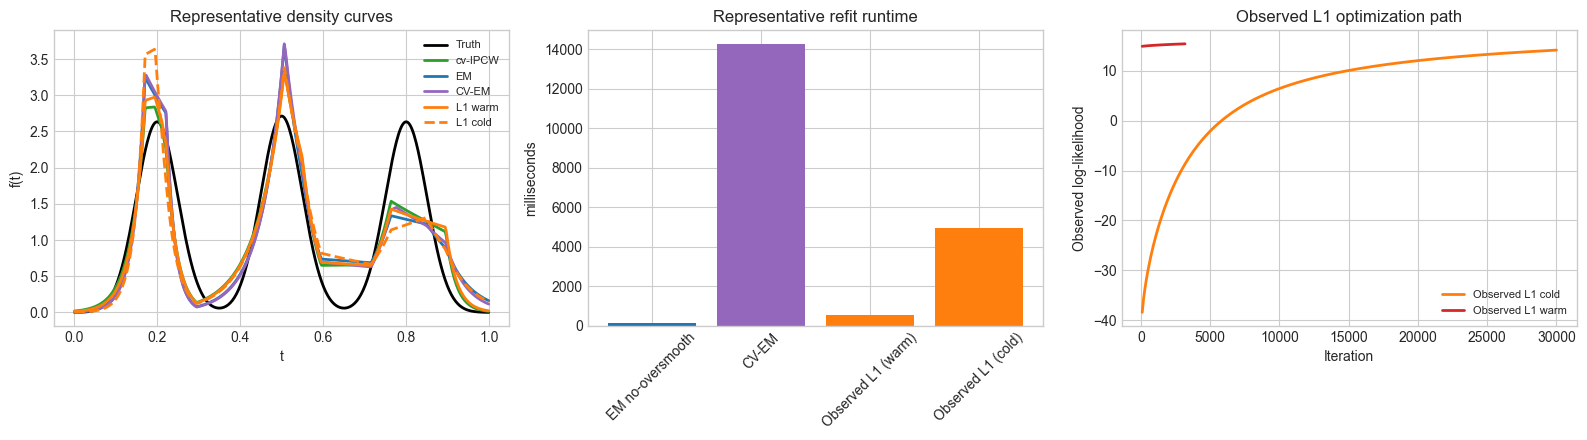

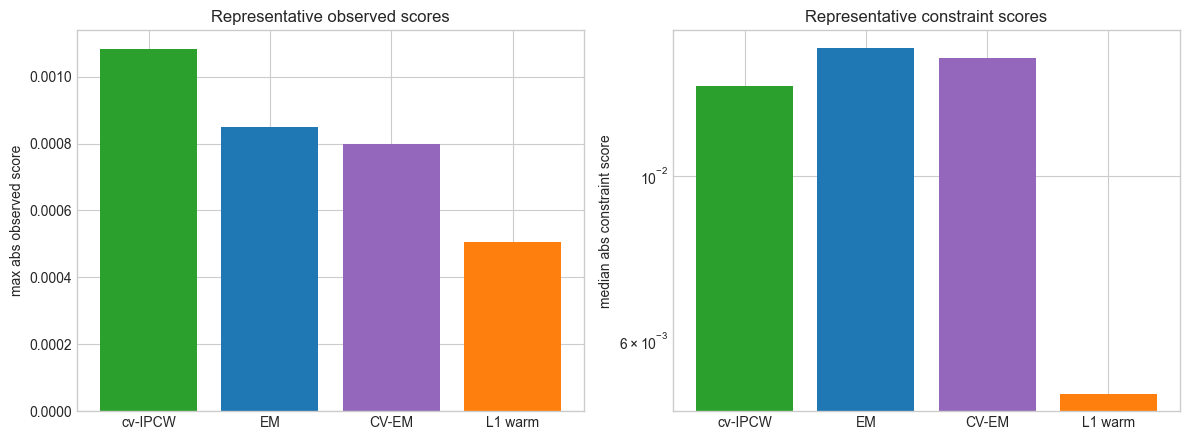

,t,truth,cv_ipcw,em,cvem,l1_warm,l1_cold
0,0.25,0.722358,0.730176,0.718410,0.717561,0.728246,0.726200
1,0.50,0.500000,0.522245,0.530147,0.531177,0.524753,0.525394
2,0.75,0.277642,0.218648,0.218448,0.222613,0.218457,0.211029


In [5]:
l1_history_df = pd.concat(
    [
        l1_history_frame(l1_cold, "Observed L1 cold"),
        l1_history_frame(l1_warm, "Observed L1 warm"),
    ],
    ignore_index=True,
)

plot_grid = np.linspace(0.001, 0.999, 400)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(plot_grid, truth["density_fn"](plot_grid), color="black", linewidth=2, label="Truth")
axes[0].plot(plot_grid, stage1_estimator.get_density_at_points(plot_grid), color="tab:green", linewidth=2, label="cv-IPCW")
axes[0].plot(plot_grid, em_run["estimator"].get_density_at_points(plot_grid), color="tab:blue", linewidth=2, label="EM")
axes[0].plot(plot_grid, cvem_run["estimator"].get_density_at_points(plot_grid), color="tab:purple", linewidth=2, label="CV-EM")
axes[0].plot(plot_grid, l1_warm["estimator"].get_density_at_points(plot_grid), color="tab:orange", linewidth=2, label="L1 warm")
axes[0].plot(plot_grid, l1_cold["estimator"].get_density_at_points(plot_grid), color="tab:orange", linewidth=2, linestyle="--", label="L1 cold")
axes[0].set_title("Representative density curves")
axes[0].set_xlabel("t")
axes[0].set_ylabel("f(t)")
axes[0].legend(fontsize=8)

runtime_plot_df = representative_refit_runtime_df.copy()
runtime_colors = ["tab:blue", "tab:purple", "tab:orange", "tab:orange"]
axes[1].bar(runtime_plot_df["method"], 1000.0 * runtime_plot_df["runtime_seconds"], color=runtime_colors)
axes[1].set_title("Representative refit runtime")
axes[1].set_ylabel("milliseconds")
axes[1].tick_params(axis="x", rotation=45)

for label, color in [("Observed L1 cold", "tab:orange"), ("Observed L1 warm", "tab:red")]:
    sub = l1_history_df[l1_history_df["run"] == label]
    axes[2].plot(sub["iteration"], sub["log_likelihood"], linewidth=2, label=label, color=color)
axes[2].set_title("Observed L1 optimization path")
axes[2].set_xlabel("Iteration")
axes[2].set_ylabel("Observed log-likelihood")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

representative_score_plot_df = representative_df[
    representative_df["method"].isin(["cv-IPCW", "EM no-oversmooth", "CV-EM", "Observed L1 (warm)"])
].copy()
representative_score_plot_df["plot_label"] = ["cv-IPCW", "EM", "CV-EM", "L1 warm"]
representative_score_colors = ["tab:green", "tab:blue", "tab:purple", "tab:orange"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(
    representative_score_plot_df["plot_label"],
    representative_score_plot_df["max_abs_observed_score"],
    color=representative_score_colors,
)
axes[0].set_title("Representative observed scores")
axes[0].set_ylabel("max abs observed score")

axes[1].bar(
    representative_score_plot_df["plot_label"],
    representative_score_plot_df["median_abs_constraint_score"],
    color=representative_score_colors,
)
axes[1].set_title("Representative constraint scores")
axes[1].set_ylabel("median abs constraint score")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

survival_snapshot = pd.DataFrame(
    {
        "t": [0.25, 0.5, 0.75],
        "truth": truth["survival_fn"](np.array([0.25, 0.5, 0.75])),
        "cv_ipcw": evaluate_survival_on_grid(stage1_estimator, np.array([0.25, 0.5, 0.75])),
        "em": evaluate_survival_on_grid(em_run["estimator"], np.array([0.25, 0.5, 0.75])),
        "cvem": evaluate_survival_on_grid(cvem_run["estimator"], np.array([0.25, 0.5, 0.75])),
        "l1_warm": evaluate_survival_on_grid(l1_warm["estimator"], np.array([0.25, 0.5, 0.75])),
        "l1_cold": evaluate_survival_on_grid(l1_cold["estimator"], np.array([0.25, 0.5, 0.75])),
    }
)

display(survival_snapshot)

In [6]:
# Small-MC sweep in parallel.

with tqdm_joblib(tqdm(total=len(SEED_SWEEP), desc=f"Small MC sweep ({N_WORKERS} workers)")):
    seed_results = Parallel(n_jobs=N_WORKERS, backend="loky")(
        delayed(run_small_mc_seed)(seed) for seed in SEED_SWEEP
    )

runtime_rows = [result["runtime_row"] for result in seed_results]
l1_seed_rows = [result["l1_row"] for result in seed_results]

runtime_summary = pd.DataFrame(runtime_rows).sort_values("seed").reset_index(drop=True)
l1_seed_summary = pd.DataFrame(l1_seed_rows).sort_values("seed").reset_index(drop=True)

method_rows = [row for result in seed_results for row in result["method_rows"]]
pointwise_rows = [row for result in seed_results for row in result["pointwise_rows"]]
method_summary = pd.DataFrame(method_rows).sort_values(["seed", "method"]).reset_index(drop=True)
pointwise_summary = pd.DataFrame(pointwise_rows).sort_values(
    ["estimand", "method", "eval_point", "seed"]
).reset_index(drop=True)

runtime_overview = pd.DataFrame(
    [
        {
            "n_seeds": int(runtime_summary.shape[0]),
            "l1_warm_faster_than_em": int(np.sum(runtime_summary["em_minus_l1_warm_ms"] > 0)),
            "l1_warm_faster_than_cvem": int(np.sum(runtime_summary["cvem_minus_l1_warm_ms"] > 0)),
            "l1_warm_smaller_observed_score_than_em": int(np.sum(runtime_summary["observed_score_reduction_vs_em"] > 0)),
            "l1_warm_smaller_observed_score_than_cvem": int(np.sum(runtime_summary["observed_score_reduction_vs_cvem"] > 0)),
            "l1_warm_smaller_constraint_score_than_em": int(np.sum(runtime_summary["constraint_score_reduction_vs_em"] > 0)),
            "l1_warm_smaller_constraint_score_than_cvem": int(np.sum(runtime_summary["constraint_score_reduction_vs_cvem"] > 0)),
            "l1_warm_smaller_density_mse_than_em": int(np.sum(runtime_summary["density_mse_reduction_vs_em"] > 0)),
            "l1_warm_smaller_density_mse_than_cvem": int(np.sum(runtime_summary["density_mse_reduction_vs_cvem"] > 0)),
            "l1_warm_smaller_survival_mse_than_em": int(np.sum(runtime_summary["survival_mse_reduction_vs_em"] > 0)),
            "l1_warm_smaller_survival_mse_than_cvem": int(np.sum(runtime_summary["survival_mse_reduction_vs_cvem"] > 0)),
            "median_em_runtime_ms": float(1000.0 * np.median(runtime_summary["em_runtime_seconds"])),
            "median_cvem_runtime_ms": float(1000.0 * np.median(runtime_summary["cvem_runtime_seconds"])),
            "median_l1_warm_runtime_ms": float(1000.0 * np.median(runtime_summary["l1_warm_runtime_seconds"])),
            "median_em_minus_l1_warm_ms": float(np.median(runtime_summary["em_minus_l1_warm_ms"])),
            "median_cvem_minus_l1_warm_ms": float(np.median(runtime_summary["cvem_minus_l1_warm_ms"])),
            "median_l1_warm_minus_em_loglik": float(np.median(runtime_summary["l1_warm_minus_em_loglik"])),
            "median_l1_warm_minus_cvem_loglik": float(np.median(runtime_summary["l1_warm_minus_cvem_loglik"])),
            "median_density_mse_reduction_vs_em": float(np.nanmedian(runtime_summary["density_mse_reduction_vs_em"])),
            "median_density_mse_reduction_vs_cvem": float(np.nanmedian(runtime_summary["density_mse_reduction_vs_cvem"])),
            "median_survival_mse_reduction_vs_em": float(np.nanmedian(runtime_summary["survival_mse_reduction_vs_em"])),
            "median_survival_mse_reduction_vs_cvem": float(np.nanmedian(runtime_summary["survival_mse_reduction_vs_cvem"])),
        }
    ]
)
l1_overview = pd.DataFrame(
    [
        {
            "n_seeds": int(l1_seed_summary.shape[0]),
            "warm_faster_runtime": int(np.sum(l1_seed_summary["runtime_gain_ms"] > 0)),
            "warm_higher_observed_loglik": int(np.sum(l1_seed_summary["loglik_gain_from_warm"] > 0)),
            "warm_smaller_observed_score": int(np.sum(l1_seed_summary["observed_score_reduction"] > 0)),
            "warm_smaller_constraint_score": int(np.sum(l1_seed_summary["constraint_score_reduction"] > 0)),
            "warm_smaller_density_mse": int(np.sum(l1_seed_summary["density_mse_reduction"] > 0)),
            "warm_smaller_survival_mse": int(np.sum(l1_seed_summary["survival_mse_reduction"] > 0)),
            "warm_fewer_iterations": int(np.sum(l1_seed_summary["iteration_gain"] > 0)),
            "median_runtime_gain_ms": float(np.median(l1_seed_summary["runtime_gain_ms"])),
            "median_loglik_gain": float(np.median(l1_seed_summary["loglik_gain_from_warm"])),
            "median_observed_score_reduction": float(np.nanmedian(l1_seed_summary["observed_score_reduction"])),
            "median_constraint_score_reduction": float(np.nanmedian(l1_seed_summary["constraint_score_reduction"])),
            "median_density_mse_reduction": float(np.nanmedian(l1_seed_summary["density_mse_reduction"])),
            "median_survival_mse_reduction": float(np.nanmedian(l1_seed_summary["survival_mse_reduction"])),
            "median_iteration_gain": float(np.median(l1_seed_summary["iteration_gain"])),
        }
    ]
)
method_median_summary = (
    method_summary.groupby("method", as_index=False)
    .agg(
        n_seeds=("seed", "size"),
        median_runtime_seconds=("runtime_seconds", "median"),
        median_observed_loglik=("observed_loglik", "median"),
        median_max_abs_observed_score=("max_abs_observed_score", "median"),
        median_median_abs_constraint_score=("median_abs_constraint_score", "median"),
        median_density_pointwise_mse=("density_pointwise_mse", "median"),
        median_survival_pointwise_mse=("survival_pointwise_mse", "median"),
    )
)
method_median_summary["median_runtime_ms"] = 1000.0 * method_median_summary["median_runtime_seconds"]

pointwise_metric_rows = []
for (method, estimand, eval_point), group in pointwise_summary.groupby(
    ["method", "estimand", "eval_point"],
    sort=True,
):
    estimates = group["estimate"].to_numpy(dtype=float)
    truth_value = float(group["truth"].iloc[0])
    mean_estimate = float(np.mean(estimates))
    bias = float(mean_estimate - truth_value)
    variance = float(np.mean((estimates - mean_estimate) ** 2))
    mse = float(np.mean(np.square(estimates - truth_value)))
    pointwise_metric_rows.append(
        {
            "method": method,
            "estimand": estimand,
            "eval_point": float(eval_point),
            "truth": truth_value,
            "mean_estimate": mean_estimate,
            "bias": bias,
            "variance": variance,
            "mse": mse,
        }
    )
pointwise_metric_summary = pd.DataFrame(pointwise_metric_rows).sort_values(
    ["estimand", "method", "eval_point"]
).reset_index(drop=True)
pointwise_metric_overview = (
    pointwise_metric_summary.groupby(["method", "estimand"], as_index=False)
    .agg(
        mean_abs_bias=("bias", lambda s: float(np.mean(np.abs(np.asarray(s, dtype=float))))),
        mean_variance=("variance", "mean"),
        mean_mse=("mse", "mean"),
    )
)

display(runtime_summary)
display(runtime_overview)
display(l1_seed_summary)
display(l1_overview)
display(method_median_summary)
display(pointwise_metric_overview)

Small MC sweep (5 workers):   0%|          | 0/50 [00:00<?, ?it/s]/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another

,seed,support_size,stage1_observed_loglik,stage1_max_abs_observed_score,stage1_median_abs_constraint_score,stage1_density_pointwise_mse,stage1_survival_pointwise_mse,em_runtime_seconds,cvem_runtime_seconds,l1_warm_runtime_seconds,...,em_density_pointwise_mse,cvem_density_pointwise_mse,l1_warm_density_pointwise_mse,density_mse_reduction_vs_em,density_mse_reduction_vs_cvem,em_survival_pointwise_mse,cvem_survival_pointwise_mse,l1_warm_survival_pointwise_mse,survival_mse_reduction_vs_em,survival_mse_reduction_vs_cvem
0,1,16,0.065095,0.001156,0.014779,0.293431,0.000669,0.163867,16.684008,0.029089,...,0.224185,0.355815,0.282137,-0.057952,0.073678,0.000595,0.000573,0.000607,-0.000013,-0.000034
1,2,8,-0.060453,0.000966,0.017789,0.444434,0.002464,0.126506,16.395986,3.345909,...,0.561039,0.356552,0.467719,0.093319,-0.111168,0.002694,0.002317,0.002452,0.000242,-0.000135
2,3,19,0.074145,0.001084,0.013222,0.203411,0.000717,0.173646,16.937203,0.607387,...,0.250314,0.241122,0.223989,0.026325,0.017133,0.000805,0.000753,0.000744,0.000061,0.000009
3,4,20,0.091913,0.000221,0.003244,0.219727,0.001915,0.170188,19.404571,0.001759,...,0.227721,0.256922,0.219906,0.007816,0.037016,0.001631,0.001640,0.001918,-0.000287,-0.000278
4,5,12,-0.059409,0.001291,0.010294,0.209713,0.000851,0.140097,15.490763,0.252484,...,0.238289,0.221821,0.218293,0.019996,0.003528,0.000802,0.000751,0.000828,-0.000027,-0.000078
5,6,20,0.036654,0.000334,0.004101,0.146178,0.004947,0.214885,17.789356,0.001508,...,0.174103,0.188836,0.145711,0.028393,0.043126,0.004823,0.004839,0.004913,-0.000089,-0.000073
6,7,10,0.018606,0.000875,0.008195,0.147305,0.001203,0.145616,15.567272,0.260116,...,0.088797,0.406724,0.110430,-0.021633,0.296294,0.001104,0.001035,0.001165,-0.000061,-0.000130
7,8,1,-0.212513,0.020348,0.010729,0.866955,0.003391,0.044375,9.846208,0.025612,...,0.890109,0.875877,0.886747,0.003362,-0.010870,0.005503,0.004990,0.005188,0.000315,-0.000198
8,9,17,-0.007909,0.000831,0.006967,0.772723,0.004173,0.152950,17.159575,0.838430,...,0.423993,1.518602,0.795638,-0.371645,0.722964,0.003898,0.004151,0.004207,-0.000309,-0.000056
9,10,20,0.193271,0.000225,0.002578,0.289600,0.001230,0.164422,19.178958,0.001678,...,0.329580,0.376926,0.289531,0.040049,0.087395,0.001331,0.001339,0.001234,0.000097,0.000105


,n_seeds,l1_warm_faster_than_em,l1_warm_faster_than_cvem,l1_warm_smaller_observed_score_than_em,l1_warm_smaller_observed_score_than_cvem,l1_warm_smaller_constraint_score_than_em,l1_warm_smaller_constraint_score_than_cvem,l1_warm_smaller_density_mse_than_em,l1_warm_smaller_density_mse_than_cvem,l1_warm_smaller_survival_mse_than_em,...,median_cvem_runtime_ms,median_l1_warm_runtime_ms,median_em_minus_l1_warm_ms,median_cvem_minus_l1_warm_ms,median_l1_warm_minus_em_loglik,median_l1_warm_minus_cvem_loglik,median_density_mse_reduction_vs_em,median_density_mse_reduction_vs_cvem,median_survival_mse_reduction_vs_em,median_survival_mse_reduction_vs_cvem
0,50,27,50,45,40,47,47,33,38,28,...,18114.726709,94.531,36.303083,17826.879687,-0.002649,-0.005676,0.006675,0.041086,0.000044,-0.000029


,seed,support_size,warm_runtime_seconds,cold_runtime_seconds,runtime_gain_ms,warm_observed_loglik,cold_observed_loglik,loglik_gain_from_warm,warm_max_abs_observed_score,cold_max_abs_observed_score,...,constraint_score_reduction,warm_density_pointwise_mse,cold_density_pointwise_mse,density_mse_reduction,warm_survival_pointwise_mse,cold_survival_pointwise_mse,survival_mse_reduction,warm_iterations,cold_iterations,iteration_gain
0,1,16,0.029089,4.597759,4568.670584,0.065222,0.053085,1.213690e-02,0.000445,0.000658,...,0.000576,0.282137,0.157775,-0.124362,0.000607,0.000553,-0.000055,173,30000,29827
1,2,8,3.345909,4.478107,1132.198168,-0.045463,-0.064378,1.891474e-02,0.000283,0.000313,...,-0.003550,0.467719,0.610077,0.142358,0.002452,0.002833,0.000381,21006,30000,8994
2,3,19,0.607387,5.522754,4915.367041,0.076784,0.070469,6.314851e-03,0.000506,0.000480,...,-0.000508,0.223989,0.284838,0.060849,0.000744,0.000992,0.000248,3192,30000,26808
3,4,20,0.001759,5.811901,5810.142083,0.091915,0.075323,1.659227e-02,0.000242,0.000415,...,0.002452,0.219906,0.244139,0.024234,0.001918,0.002050,0.000132,2,30000,29998
4,5,12,0.252484,1.500110,1247.626500,-0.058092,-0.058694,6.014457e-04,0.000460,0.000445,...,-0.000562,0.218293,0.267707,0.049414,0.000828,0.000998,0.000170,1605,9830,8225
5,6,20,0.001508,6.029015,6027.506541,0.036655,0.021589,1.506635e-02,0.000298,0.000374,...,0.000544,0.145711,0.121740,-0.023971,0.004913,0.004809,-0.000103,2,30000,29998
6,7,10,0.260116,1.584020,1323.903250,0.021753,0.019942,1.811109e-03,0.000655,0.000545,...,-0.001202,0.110430,0.091659,-0.018771,0.001165,0.001240,0.000075,1633,10502,8869
7,8,1,0.025612,0.031606,5.993958,-0.210116,-0.210116,1.591324e-08,0.004748,0.004782,...,0.000023,0.886747,0.886802,0.000055,0.005188,0.005193,0.000005,186,235,49
8,9,17,0.838430,4.193826,3355.395916,-0.003600,-0.003150,-4.498468e-04,0.000430,0.000442,...,-0.002138,0.795638,0.321426,-0.474213,0.004207,0.004140,-0.000067,4916,26202,21286
9,10,20,0.001678,5.984595,5982.917416,0.193272,0.181460,1.181186e-02,0.000199,0.000445,...,0.001329,0.289531,0.175471,-0.114061,0.001234,0.001289,0.000055,2,30000,29998


,n_seeds,warm_faster_runtime,warm_higher_observed_loglik,warm_smaller_observed_score,warm_smaller_constraint_score,warm_smaller_density_mse,warm_smaller_survival_mse,warm_fewer_iterations,median_runtime_gain_ms,median_loglik_gain,median_observed_score_reduction,median_constraint_score_reduction,median_density_mse_reduction,median_survival_mse_reduction,median_iteration_gain
0,50,50,38,22,13,26,34,50,3783.832272,0.001275,-0.000006,-0.000672,0.000517,0.000072,22323.5


,method,n_seeds,median_runtime_seconds,median_observed_loglik,median_max_abs_observed_score,median_median_abs_constraint_score,median_density_pointwise_mse,median_survival_pointwise_mse,median_runtime_ms
0,CV-EM,50,18.114727,0.043112,0.001000,0.021263,0.299542,0.001639,18114.726709
1,EM no-oversmooth,50,0.163604,0.042056,0.000979,0.014226,0.247330,0.001663,163.604146
2,Observed L1 (cold),50,4.261344,0.034587,0.000397,0.002960,0.248524,0.001568,4261.343687
3,Observed L1 (warm),50,0.094531,0.036239,0.000407,0.003893,0.233391,0.001570,94.531000
4,cv-IPCW,50,NaN,0.036238,0.000865,0.010136,0.239208,0.001768,NaN


,method,estimand,mean_abs_bias,mean_variance,mean_mse
0,CV-EM,density,0.194430,0.318274,0.371242
1,CV-EM,survival,0.008737,0.002009,0.002124
2,EM no-oversmooth,density,0.232740,0.239945,0.312103
3,EM no-oversmooth,survival,0.011555,0.002017,0.002211
4,Observed L1 (cold),density,0.274686,0.192979,0.302205
5,Observed L1 (cold),survival,0.013406,0.001952,0.002233
6,Observed L1 (warm),density,0.231962,0.245646,0.313939
7,Observed L1 (warm),survival,0.011194,0.001968,0.002142
8,cv-IPCW,density,0.232465,0.241572,0.310132
9,cv-IPCW,survival,0.012238,0.001949,0.002161


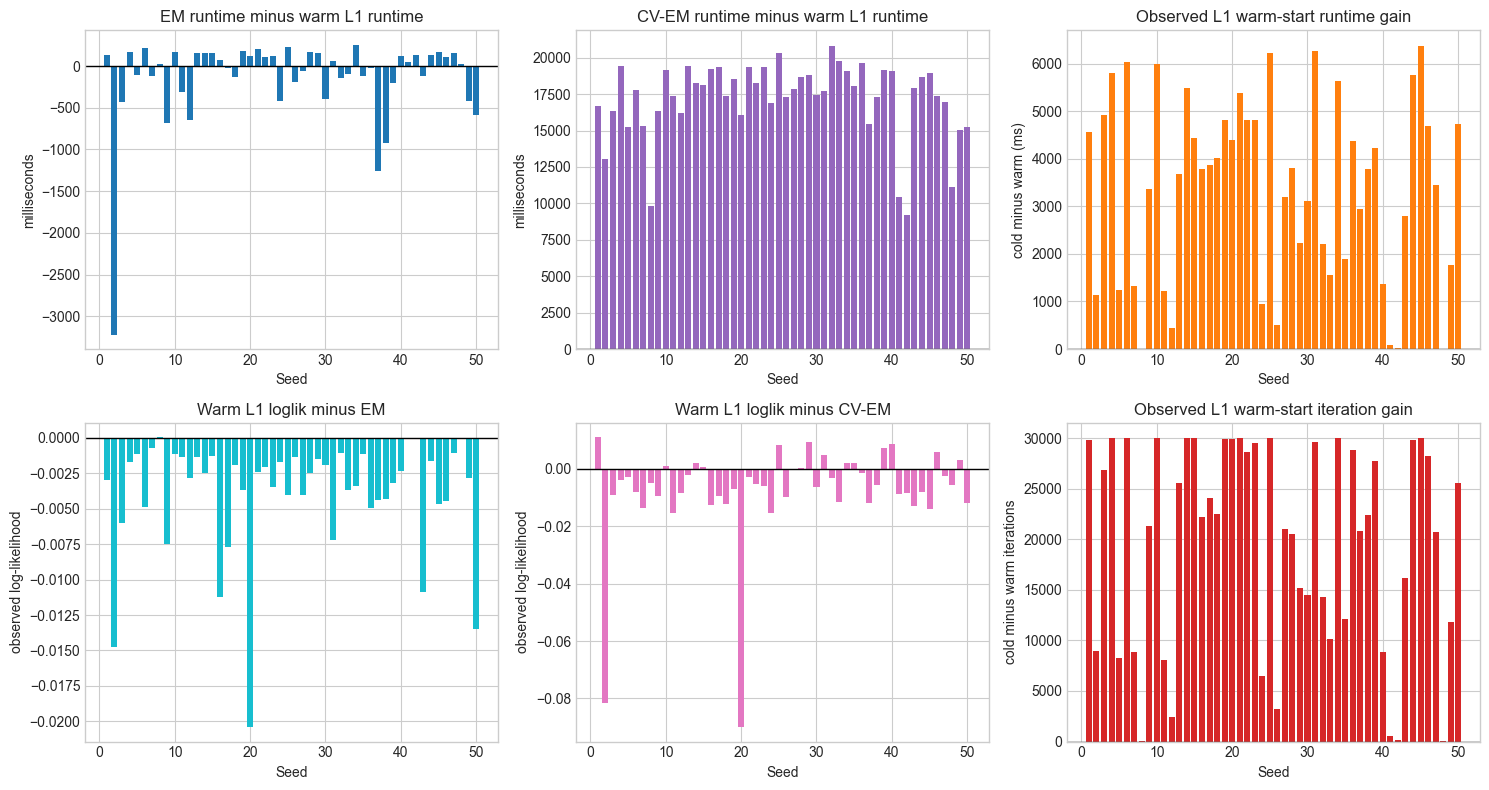

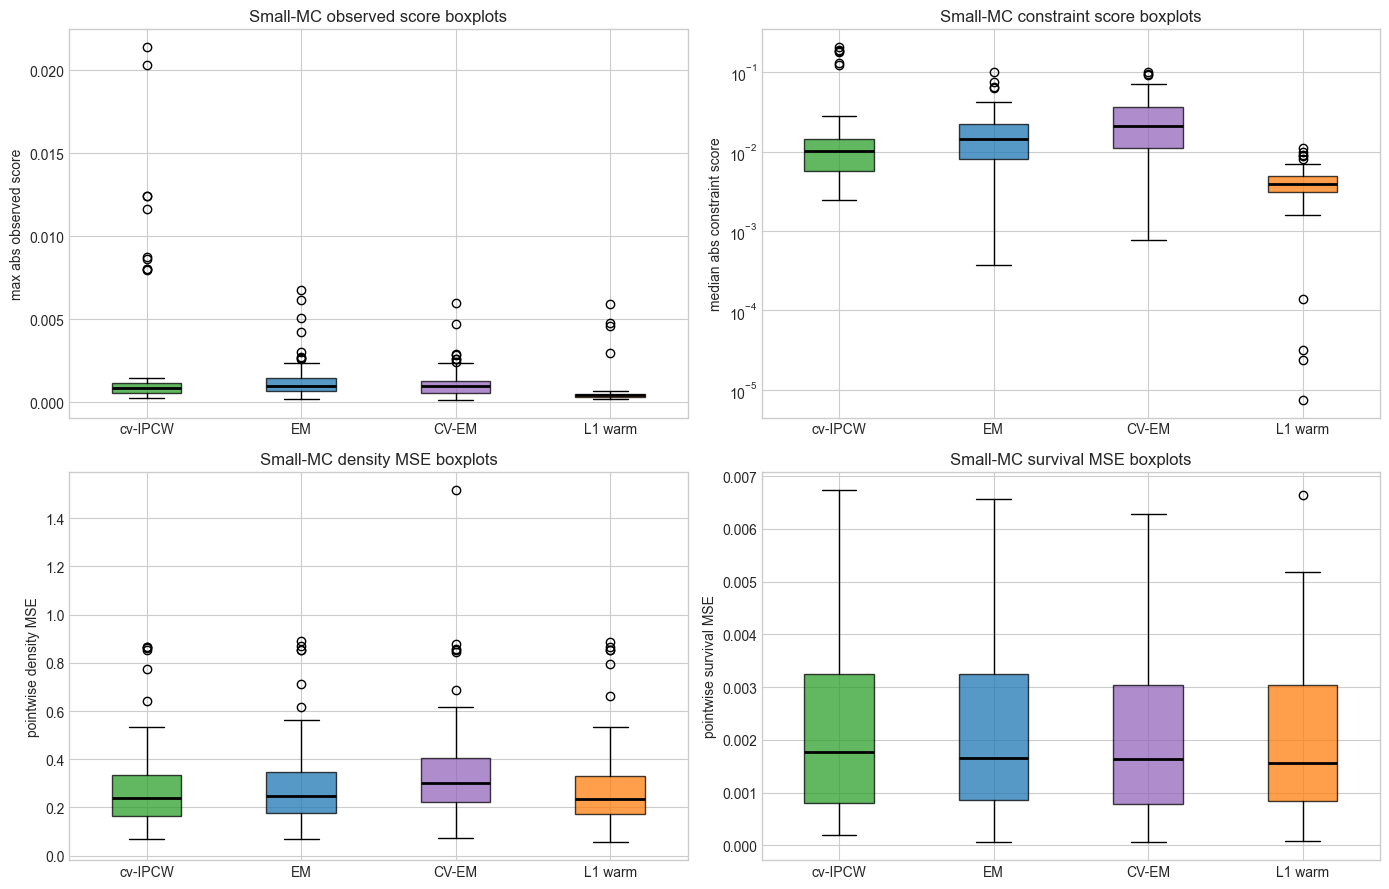

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0, 0].axhline(0.0, color="black", linewidth=1)
axes[0, 0].bar(runtime_summary["seed"], runtime_summary["em_minus_l1_warm_ms"], color="tab:blue")
axes[0, 0].set_title("EM runtime minus warm L1 runtime")
axes[0, 0].set_xlabel("Seed")
axes[0, 0].set_ylabel("milliseconds")

axes[0, 1].axhline(0.0, color="black", linewidth=1)
axes[0, 1].bar(runtime_summary["seed"], runtime_summary["cvem_minus_l1_warm_ms"], color="tab:purple")
axes[0, 1].set_title("CV-EM runtime minus warm L1 runtime")
axes[0, 1].set_xlabel("Seed")
axes[0, 1].set_ylabel("milliseconds")

axes[0, 2].axhline(0.0, color="black", linewidth=1)
axes[0, 2].bar(l1_seed_summary["seed"], l1_seed_summary["runtime_gain_ms"], color="tab:orange")
axes[0, 2].set_title("Observed L1 warm-start runtime gain")
axes[0, 2].set_xlabel("Seed")
axes[0, 2].set_ylabel("cold minus warm (ms)")

axes[1, 0].axhline(0.0, color="black", linewidth=1)
axes[1, 0].bar(runtime_summary["seed"], runtime_summary["l1_warm_minus_em_loglik"], color="tab:cyan")
axes[1, 0].set_title("Warm L1 loglik minus EM")
axes[1, 0].set_xlabel("Seed")
axes[1, 0].set_ylabel("observed log-likelihood")

axes[1, 1].axhline(0.0, color="black", linewidth=1)
axes[1, 1].bar(runtime_summary["seed"], runtime_summary["l1_warm_minus_cvem_loglik"], color="tab:pink")
axes[1, 1].set_title("Warm L1 loglik minus CV-EM")
axes[1, 1].set_xlabel("Seed")
axes[1, 1].set_ylabel("observed log-likelihood")

axes[1, 2].axhline(0.0, color="black", linewidth=1)
axes[1, 2].bar(l1_seed_summary["seed"], l1_seed_summary["iteration_gain"], color="tab:red")
axes[1, 2].set_title("Observed L1 warm-start iteration gain")
axes[1, 2].set_xlabel("Seed")
axes[1, 2].set_ylabel("cold minus warm iterations")

plt.tight_layout()
plt.show()

boxplot_methods = ["cv-IPCW", "EM no-oversmooth", "CV-EM", "Observed L1 (warm)"]
boxplot_labels = ["cv-IPCW", "EM", "CV-EM", "L1 warm"]
boxplot_colors = {
    "cv-IPCW": "tab:green",
    "EM no-oversmooth": "tab:blue",
    "CV-EM": "tab:purple",
    "Observed L1 (warm)": "tab:orange",
}
plot_method_summary = method_summary[method_summary["method"].isin(boxplot_methods)].copy()

observed_box_data = [
    plot_method_summary.loc[plot_method_summary["method"] == method, "max_abs_observed_score"].to_numpy()
    for method in boxplot_methods
]
constraint_box_data = [
    np.maximum(
        plot_method_summary.loc[plot_method_summary["method"] == method, "median_abs_constraint_score"].to_numpy(),
        1e-12,
    )
    for method in boxplot_methods
]
density_mse_box_data = [
    plot_method_summary.loc[plot_method_summary["method"] == method, "density_pointwise_mse"].to_numpy()
    for method in boxplot_methods
]
survival_mse_box_data = [
    plot_method_summary.loc[plot_method_summary["method"] == method, "survival_pointwise_mse"].to_numpy()
    for method in boxplot_methods
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
observed_box = axes[0, 0].boxplot(observed_box_data, tick_labels=boxplot_labels, patch_artist=True)
constraint_box = axes[0, 1].boxplot(constraint_box_data, tick_labels=boxplot_labels, patch_artist=True)
density_mse_box = axes[1, 0].boxplot(density_mse_box_data, tick_labels=boxplot_labels, patch_artist=True)
survival_mse_box = axes[1, 1].boxplot(survival_mse_box_data, tick_labels=boxplot_labels, patch_artist=True)

for boxplot in [observed_box, constraint_box, density_mse_box, survival_mse_box]:
    for patch, method in zip(boxplot["boxes"], boxplot_methods):
        patch.set_facecolor(boxplot_colors[method])
        patch.set_alpha(0.75)
    for median in boxplot["medians"]:
        median.set_color("black")
        median.set_linewidth(2)

axes[0, 0].set_title("Small-MC observed score boxplots")
axes[0, 0].set_ylabel("max abs observed score")

axes[0, 1].set_title("Small-MC constraint score boxplots")
axes[0, 1].set_ylabel("median abs constraint score")
axes[0, 1].set_yscale("log")

axes[1, 0].set_title("Small-MC density MSE boxplots")
axes[1, 0].set_ylabel("pointwise density MSE")

axes[1, 1].set_title("Small-MC survival MSE boxplots")
axes[1, 1].set_ylabel("pointwise survival MSE")

plt.tight_layout()
plt.show()

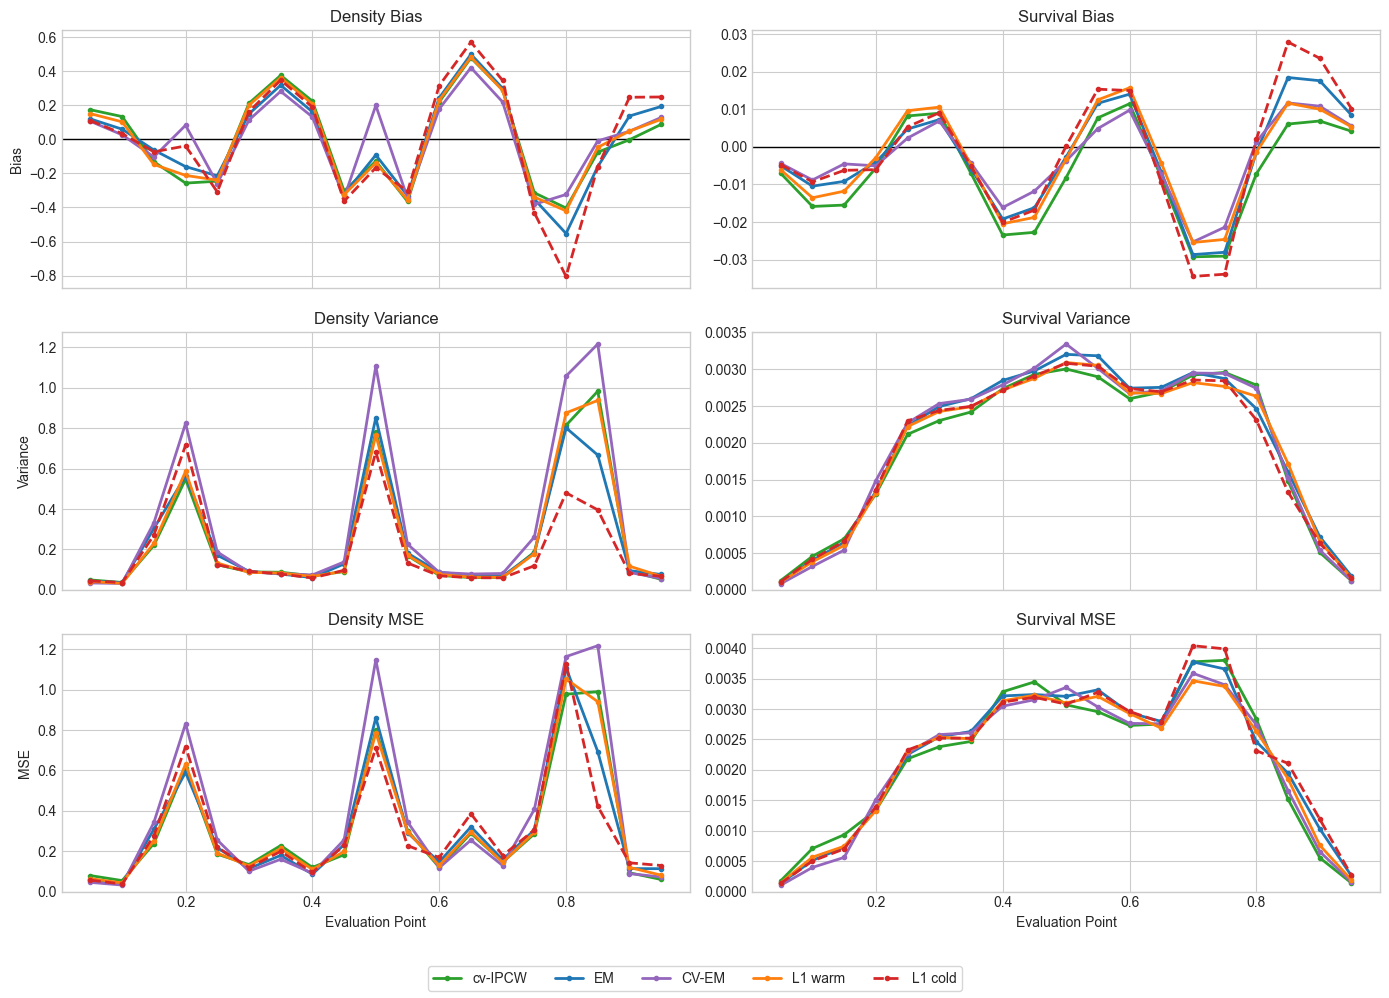

In [8]:
pointwise_plot_methods = [
    "cv-IPCW",
    "EM no-oversmooth",
    "CV-EM",
    "Observed L1 (warm)",
    "Observed L1 (cold)",
]
pointwise_plot_labels = {
    "cv-IPCW": "cv-IPCW",
    "EM no-oversmooth": "EM",
    "CV-EM": "CV-EM",
    "Observed L1 (warm)": "L1 warm",
    "Observed L1 (cold)": "L1 cold",
}
pointwise_plot_colors = {
    "cv-IPCW": "tab:green",
    "EM no-oversmooth": "tab:blue",
    "CV-EM": "tab:purple",
    "Observed L1 (warm)": "tab:orange",
    "Observed L1 (cold)": "tab:red",
}
pointwise_plot_styles = {
    "cv-IPCW": "-",
    "EM no-oversmooth": "-",
    "CV-EM": "-",
    "Observed L1 (warm)": "-",
    "Observed L1 (cold)": "--",
}
metric_order = ["bias", "variance", "mse"]
estimand_order = ["density", "survival"]
metric_labels = {"bias": "Bias", "variance": "Variance", "mse": "MSE"}
estimand_labels = {"density": "Density", "survival": "Survival"}

fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex="col")

for row_idx, metric in enumerate(metric_order):
    for col_idx, estimand in enumerate(estimand_order):
        ax = axes[row_idx, col_idx]
        if metric == "bias":
            ax.axhline(0.0, color="black", linewidth=1)

        for method in pointwise_plot_methods:
            method_df = pointwise_metric_summary[
                (pointwise_metric_summary["method"] == method)
                & (pointwise_metric_summary["estimand"] == estimand)
            ].sort_values("eval_point")
            ax.plot(
                method_df["eval_point"],
                method_df[metric],
                color=pointwise_plot_colors[method],
                linestyle=pointwise_plot_styles[method],
                linewidth=2,
                marker="o",
                markersize=3,
                label=pointwise_plot_labels[method],
            )

        ax.set_title(f"{estimand_labels[estimand]} {metric_labels[metric]}")
        if col_idx == 0:
            ax.set_ylabel(metric_labels[metric])
        if row_idx == len(metric_order) - 1:
            ax.set_xlabel("Evaluation Point")
        if metric in {"variance", "mse"}:
            ax.set_ylim(bottom=0.0)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=len(pointwise_plot_methods), frameon=True)
plt.tight_layout(rect=(0, 0.05, 1, 1))
plt.show()

## Takeaways

This notebook now uses the same right-censored DGP as `examples/example_right_censored_density_estimator.ipynb` and compares five fits:

- `cv-IPCW`,
- `EM` without oversmooth,
- `CV-EM` with CV over `oversmooth_factor` and `em_norm_factor`,
- observed `L1` with a cold start,
- observed `L1` with the compressed Stage 1 warm start.

The small multi-seed sweep reports four complementary diagnostics across seeds:

- exact score boxplots,
- pointwise density MSE on the grid `0.05, 0.10, ..., 0.95`,
- pointwise survival MSE on the same grid,
- pointwise bias, variance, and MSE line plots for both density and survival.

`cv-IPCW` timing is still excluded. Runtime comparisons stay focused on the refits:

- `EM` versus warm `Observed L1`,
- `CV-EM` versus warm `Observed L1`,
- warm versus cold `Observed L1`.

Use the representative tables to inspect the selected `CV-EM` hyperparameters, and use the small-MC summary tables and boxplots to read off the current score and MSE trade-offs under whatever configuration is active in the run-config cell.